In [ ]:
#step1: Importing libraries
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
import matplotlib.pyplot as plt
from tensorflow.keras.optimizers import Adam

In [ ]:
#Load MNIST dataset

(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
#step 3: Normalize pixel values

x_train = x_train / 255.0
x_test = x_test / 255.0

In [ ]:
x_train.shape
y_train.shape

(60000,)

In [ ]:
#4 to build a neural network

model=Sequential([
    Flatten(input_shape=(28,28)), # input layer
    Dense(16,activation='sigmoid'), # Hidden layer
    Dense(64,input_shape=(784,),activation='sigmoid'), # Hidden layer
    Dense(10,activation='softmax') # Output layer
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
#5 To compile the model

model.compile(optimizer=Adam(learning_rate=0.1),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [ ]:
#6 Train model

history=model.fit(x_train,y_train,epochs=5,validation_split=0.2)


Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.5277 - loss: 1.3436 - val_accuracy: 0.7620 - val_loss: 0.8172
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.7400 - loss: 0.7757 - val_accuracy: 0.7854 - val_loss: 0.7032
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7641 - loss: 0.7187 - val_accuracy: 0.7726 - val_loss: 0.6507
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.7700 - loss: 0.7079 - val_accuracy: 0.7426 - val_loss: 0.7600
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.7378 - loss: 0.7840 - val_accuracy: 0.7568 - val_loss: 0.7598


In [ ]:
model.fit(x_train,y_train,epochs=5,batch_size=32)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7945 - loss: 0.6821
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8006 - loss: 0.6758
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8242 - loss: 0.6140
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8195 - loss: 0.6107
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8155 - loss: 0.6281


In [ ]:
# test model

model.evaluate(x_test,y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8006 - loss: 0.7067


[0.6504883170127869, 0.8220000267028809]

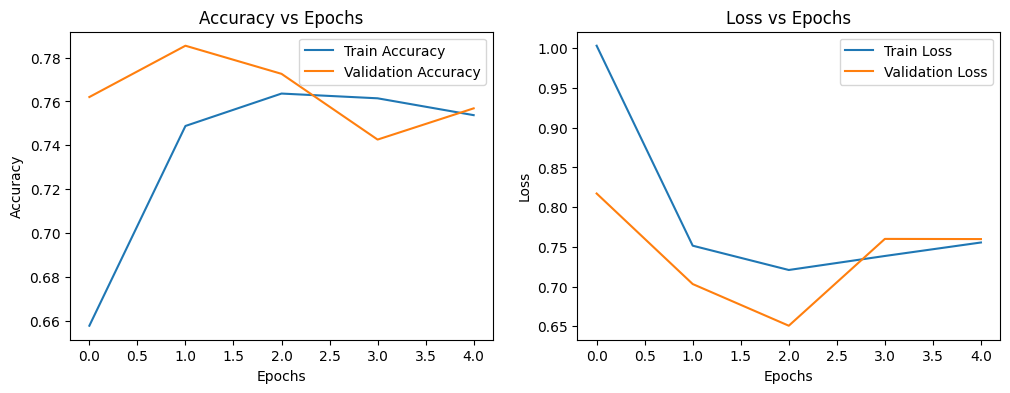

In [ ]:
# accuracy and loss function

plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'],label='Train Accuracy')
plt.plot(history.history['val_accuracy'],label='Validation Accuracy')
plt.title('Accuracy vs Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

#loss plot
plt.subplot(1,2,2)
plt.plot(history.history['loss'],label='Train Loss')
plt.plot(history.history['val_loss'],label='Validation Loss')
plt.title('Loss vs Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()